## 1. Setup & Imports

Import the libraries needed for this analysis (pandas for data handling, matplotlib/seaborn for charts, sqlite3 for the SQL section), set a consistent chart style, and define the file paths used throughout the notebook.

In [5]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150

RAW_PATH = Path("data/raw/claims_and_billing_raw.csv")
CLEAN_PATH = Path("data/clean/claims_and_billing_clean.csv")
VISUALS_DIR = Path("visuals")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load the Data

Read the raw CSV into a DataFrame and confirm it loaded correctly — check the row/column count and preview the first few rows.

In [6]:
df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 70,000 rows x 11 columns


,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,06-02-2025 00:00,1971.52,0.00,Denied,Claim Billed to Wrong Payer
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,01-05-2025 00:00,1243.80,736.05,Paid,NaN
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,23-02-2025 00:00,4854.11,2676.12,Paid,NaN
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,20-04-2025 00:00,2638.21,1861.39,Paid,NaN
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaN,1046.99,1046.99,Paid,NaN


In [4]:
import os
print(os.getcwd())

C:\Users\USER\Health_billing_Portfolio


## 3. Data Quality Assessment

Before analyzing, check for missing values, duplicates, and logical inconsistencies in the data.

In [7]:
print("Column data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Column data types:
billing_id                str
patient_id                str
encounter_id              str
insurance_provider        str
payment_method            str
claim_id                  str
claim_billing_date        str
billed_amount         float64
paid_amount           float64
claim_status              str
denial_reason             str
dtype: object

Missing values per column:
billing_id                0
patient_id                0
encounter_id              0
insurance_provider        0
payment_method            0
claim_id              10362
claim_billing_date    10362
billed_amount             0
paid_amount               0
claim_status              0
denial_reason         64002
dtype: int64


## 4. Explain the Missing Data

`claim_id`, `claim_billing_date`, and `denial_reason` all have missing values. Before deciding how to handle them, confirm whether they're genuine data errors or expected gaps.

In [8]:
# Are the missing claim_id/claim_billing_date rows all Self-pay (no insurance claim filed)?
selfpay_mask = df['payment_method'] == 'Selfpay'
print("Self-pay rows:", selfpay_mask.sum())
print("Rows missing claim_id:", df['claim_id'].isna().sum())
print("Self-pay rows missing claim_id:", df.loc[selfpay_mask, 'claim_id'].isna().sum())
print()
# Is denial_reason only missing for Paid claims (i.e. correctly blank)?
print(pd.crosstab(df['claim_status'], df['denial_reason'].isna()))

Self-pay rows: 10362
Rows missing claim_id: 10362
Self-pay rows missing claim_id: 10362

denial_reason  False  True 
claim_status               
Denied          5998      0
Paid               0  64002


## 5. Data Quality Checks

Check for duplicate records, negative amounts, and payments exceeding billed amounts — all of which would indicate genuine data errors.

In [9]:
checks = {
    "Duplicate billing_id": df['billing_id'].duplicated().sum(),
    "Duplicate encounter_id": df['encounter_id'].duplicated().sum(),
    "Negative billed_amount": (df['billed_amount'] < 0).sum(),
    "Negative paid_amount": (df['paid_amount'] < 0).sum(),
    "paid_amount > billed_amount": (df['paid_amount'] > df['billed_amount']).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v}")

Duplicate billing_id: 0
Duplicate encounter_id: 0
Negative billed_amount: 0
Negative paid_amount: 0
paid_amount > billed_amount: 0


## 6. Cleaning & Feature Engineering

Steps:
1. Parse `claim_billing_date` (format is `DD/MM/YYYY HH:MM`) into a proper date type.
2. Fill `denial_reason` with `"N/A - Paid"` for clarity, instead of leaving it blank.
3. Create billing-month / quarter fields for trend analysis.
4. Create derived financial metrics: `underpayment`, `collection_rate`, `is_denied`.

In [12]:
clean = df.copy()

# Parse dates (only present for Insurance claims)
clean['claim_billing_date'] = pd.to_datetime(
    clean['claim_billing_date'], format='%d-%m-%Y %H:%M', errors='coerce'
)

clean['billing_month'] = clean['claim_billing_date'].dt.to_period('M').astype(str)
clean['billing_quarter'] = clean['claim_billing_date'].dt.to_period('Q').astype(str)

clean['denial_reason'] = clean['denial_reason'].fillna('N/A - Paid')

clean['is_denied'] = (clean['claim_status'] == 'Denied').astype(int)
clean['underpayment'] = clean['billed_amount'] - clean['paid_amount']
clean['collection_rate'] = np.where(
    clean['billed_amount'] > 0,
    clean['paid_amount'] / clean['billed_amount'],
    np.nan
)

clean.head()

,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason,billing_month,billing_quarter,is_denied,underpayment,collection_rate
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,2025-02-06,1971.52,0.00,Denied,Claim Billed to Wrong Payer,2025-02,2025Q1,1,1971.52,0.000000
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,2025-05-01,1243.80,736.05,Paid,N/A - Paid,2025-05,2025Q2,0,507.75,0.591775
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,2025-02-23,4854.11,2676.12,Paid,N/A - Paid,2025-02,2025Q1,0,2177.99,0.551310
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,2025-04-20,2638.21,1861.39,Paid,N/A - Paid,2025-04,2025Q2,0,776.82,0.705550
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaT,1046.99,1046.99,Paid,N/A - Paid,NaN,NaN,0,0.00,1.000000


In [13]:
print(df['claim_billing_date'].dropna().head(10).tolist())

['06-02-2025 00:00', '01-05-2025 00:00', '23-02-2025 00:00', '20-04-2025 00:00', '06-02-2025 00:00', '26-02-2025 00:00', '12-02-2025 00:00', '14-03-2025 00:00', '08-03-2025 00:00', '16-04-2025 00:00']


## 7. Save the Cleaned Dataset

Export the cleaned DataFrame — this becomes the single source of truth for the rest of this notebook, and later feeds the Power BI dashboard.

In [14]:
clean.to_csv(CLEAN_PATH, index=False)
print(f"Clean dataset saved to {CLEAN_PATH} ({clean.shape[0]:,} rows)")

Clean dataset saved to data\clean\claims_and_billing_clean.csv (70,000 rows)


## 8. Headline Revenue Cycle KPIs

The core numbers that summarize the whole billing operation: how much was billed, how much was actually collected, and how big the gap is.

In [15]:
total_billed = clean['billed_amount'].sum()
total_paid = clean['paid_amount'].sum()
overall_collection_rate = total_paid / total_billed
denial_rate = clean['is_denied'].mean()
total_underpayment = clean['underpayment'].sum()
avg_claim_value = clean['billed_amount'].mean()

kpis = pd.DataFrame({
    "Metric": [
        "Total Billed", "Total Paid", "Total Underpayment/Gap",
        "Overall Collection Rate", "Overall Denial Rate", "Avg. Billed Amount per Claim",
        "Total Encounters", "Unique Patients"
    ],
    "Value": [
        f"${total_billed:,.2f}", f"${total_paid:,.2f}", f"${total_underpayment:,.2f}",
        f"{overall_collection_rate:.1%}", f"{denial_rate:.1%}", f"${avg_claim_value:,.2f}",
        f"{len(clean):,}", f"{clean['patient_id'].nunique():,}"
    ]
})
kpis

,Metric,Value
0,Total Billed,"$112,900,639.84"
1,Total Paid,"$72,845,650.54"
2,Total Underpayment/Gap,"$40,054,989.30"
3,Overall Collection Rate,64.5%
4,Overall Denial Rate,8.6%
5,Avg. Billed Amount per Claim,"$1,612.87"
6,Total Encounters,"70,000"
7,Unique Patients,"60,000"


## 9. Claims Denial Analysis

Denials are the biggest lever for recovering revenue — a denied claim is billed revenue never collected unless corrected and resubmitted. We restrict this to Insurance claims only, since Self-pay has no denial risk.

In [16]:
insurance = clean[clean['payment_method'] == 'Insurance'].copy()

denial_by_payer = (
    insurance.groupby('insurance_provider')['is_denied']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'denial_rate', 'sum': 'denied_claims', 'count': 'total_claims'})
    .sort_values('denial_rate', ascending=False)
)
denial_by_payer['denial_rate'] = (denial_by_payer['denial_rate'] * 100).round(2)
denial_by_payer

,denial_rate,denied_claims,total_claims
insurance_provider,,,
Medicaid,10.90,934,8572
Cigna,10.27,871,8481
Humana,9.99,844,8450
UHC,9.95,855,8592
Medicare,9.85,833,8460
BCBS,9.79,834,8516
Aetna,9.65,827,8567


### Denial Rate by Payer — Visualized

A horizontal bar chart makes it easy to compare denial rates across all 7 payers at a glance.

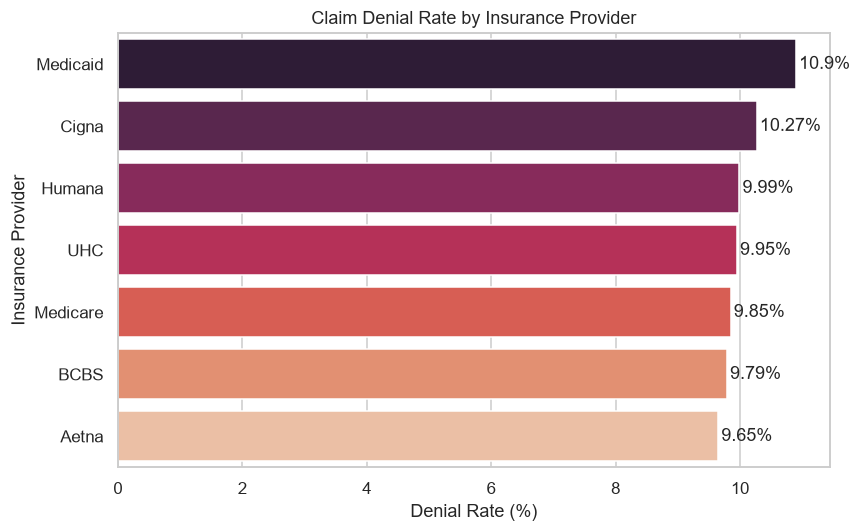

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
order = denial_by_payer.index
sns.barplot(x=denial_by_payer['denial_rate'], y=order, hue=order, palette="rocket", legend=False, ax=ax)
ax.set_xlabel("Denial Rate (%)")
ax.set_ylabel("Insurance Provider")
ax.set_title("Claim Denial Rate by Insurance Provider")
for i, v in enumerate(denial_by_payer['denial_rate']):
    ax.text(v + 0.05, i, f"{v}%", va='center')
plt.tight_layout()
plt.savefig(VISUALS_DIR / "denial_rate_by_payer.png")
plt.show()

**Interpretation:** Denial rates across all 7 payers are tightly clustered — ranging from 9.65% (Aetna) to 10.9% (Medicaid), a spread of only 1.25 percentage points. This narrow range suggests denials are driven more by **internal claim submission processes** (coding errors, missing prior authorizations, eligibility gaps) than by any single payer being unusually strict. Medicaid and Cigna have the highest denial rates and are worth investigating first, but the real opportunity lies in fixing root causes that affect claims across all payers — which the next section (top denial reasons) will help identify.

### Top Reasons for Claim Denial

Beyond *which* payer denies more, understanding *why* claims get denied tells us what to actually fix.

In [19]:
top_reasons = (
    insurance[insurance['claim_status'] == 'Denied']['denial_reason']
    .value_counts()
    .head(10)
)
top_reasons

denial_reason
Duplicate Claim                   472
Prior Authorization Required      457
Service Not Covered               437
Timely Filing Limit Exceeded      437
Coordination of Benefits Issue    436
Expired or Invalid Insurance      435
Coverage Limit Exceeded           432
Out-of-Network Provider           425
Claim Billed to Wrong Payer       422
Invalid Place of Service          416
Name: count, dtype: int64

### Top Denial Reasons — Visualized

C:\Users\USER\AppData\Local\Temp\ipykernel_3780\70112835.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, ax=ax, palette="mako")


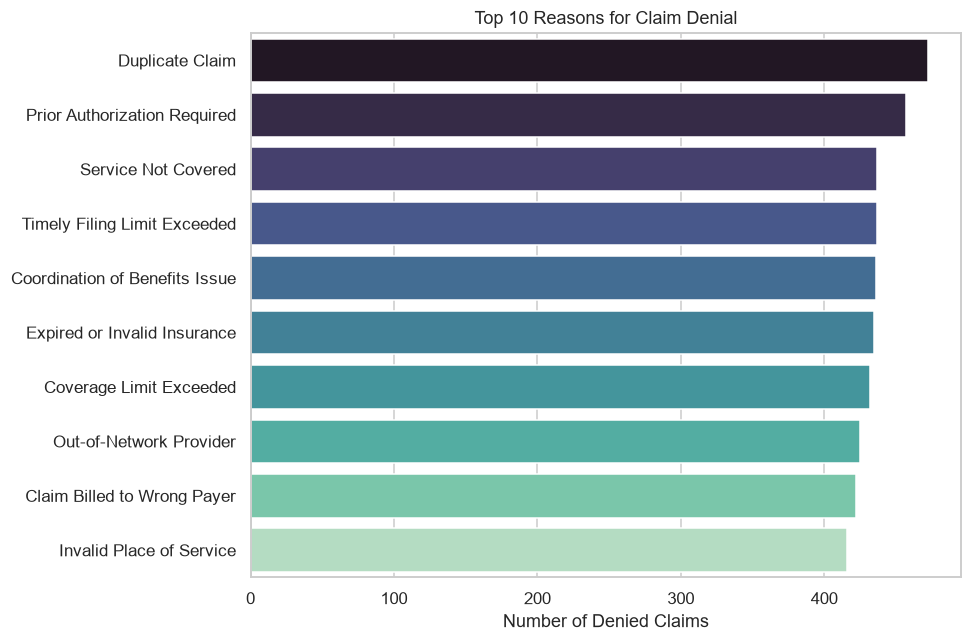

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_reasons.values, y=top_reasons.index, ax=ax, palette="mako")
ax.set_xlabel("Number of Denied Claims")
ax.set_ylabel("")
ax.set_title("Top 10 Reasons for Claim Denial")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_denial_reasons.png")
plt.show()

**Interpretation:** The top 10 denial reasons are remarkably close in frequency (416–472 occurrences each) — there's no single dominant cause responsible for most denials. Notably, **all 10 reasons are preventable through better front-end processes**, not payer disputes:

- **Duplicate Claim** (#1) and **Claim Billed to Wrong Payer** (#9) point to billing-system or workflow errors — likely fixable with better claim-tracking software or a pre-submission checklist.
- **Prior Authorization Required** (#2) and **Coverage Limit Exceeded** (#7) suggest gaps in eligibility/authorization verification *before* the visit or procedure.
- **Timely Filing Limit Exceeded** (#4) is a pure process failure — claims are being submitted too late, which is entirely within the organization's control to fix.
- **Expired or Invalid Insurance** (#6) and **Out-of-Network Provider** (#8) point to insufficient eligibility checks at patient intake.

Since no reason dominates, there's no "silver bullet" fix — this needs a broad front-desk and billing-process review rather than one targeted change.

### Denial Trend Over Time

Is the denial rate improving, worsening, or staying flat month to month? This helps distinguish a one-time issue from an ongoing pattern.

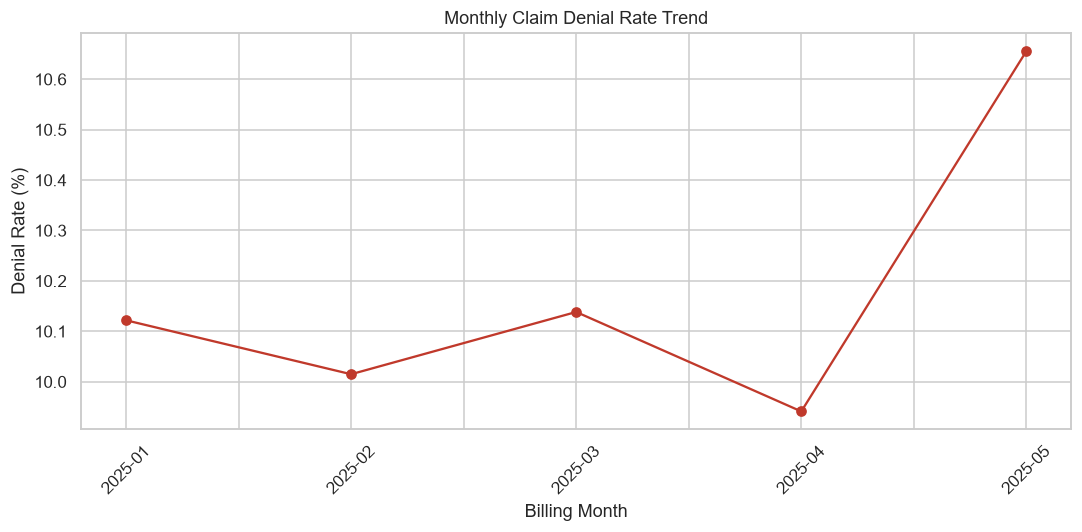

In [21]:
monthly_denials = (
    insurance.dropna(subset=['billing_month'])
    .groupby('billing_month')['is_denied']
    .mean()
    .sort_index()
    * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_denials.plot(marker='o', ax=ax, color='#c0392b')
ax.set_ylabel("Denial Rate (%)")
ax.set_xlabel("Billing Month")
ax.set_title("Monthly Claim Denial Rate Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "monthly_denial_trend.png")
plt.show()

**Interpretation:** Denial rate held fairly steady between 10.0%–10.1% from January through March, dipped to its lowest point in April (~10.0%), then **spiked sharply in May to ~10.6%** — the highest point in the whole period. This late uptick is the most actionable signal in the trend: something changed in May (a new payer policy, a staffing change, a system update, a backlog) that's worth investigating directly with the billing team, since it reverses several months of relative stability. If this were a live dashboard, this is exactly the kind of point-in-time spike that should trigger a root-cause review before it becomes the new normal.

## 10. Revenue Cycle / Collections Performance

Collection rate = paid ÷ billed. This measures how effectively billed revenue is actually converted into cash — across payers, payment methods, and time. Unlike denial rate (which only applies to insurance claims), collection rate applies to the **whole dataset**, including Self-pay.

In [22]:
collections_by_payer = (
    clean.groupby('insurance_provider')
    .agg(total_billed=('billed_amount', 'sum'),
         total_paid=('paid_amount', 'sum'))
)
collections_by_payer['collection_rate'] = (
    collections_by_payer['total_paid'] / collections_by_payer['total_billed'] * 100
).round(2)
collections_by_payer.sort_values('collection_rate')

,total_billed,total_paid,collection_rate
insurance_provider,,,
Aetna,15931881.91,10220394.03,64.15
Medicaid,16297387.90,10458464.11,64.17
Cigna,16379391.57,10552126.52,64.42
UHC,16328640.75,10533344.33,64.51
Humana,15957291.04,10324831.81,64.70
BCBS,15937527.71,10319121.06,64.75
Medicare,16068518.96,10437368.68,64.96


### Collection Rate by Payer — Visualized

C:\Users\USER\AppData\Local\Temp\ipykernel_3780\3420293293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_sorted['collection_rate'], y=data_sorted.index, ax=ax, palette="crest")


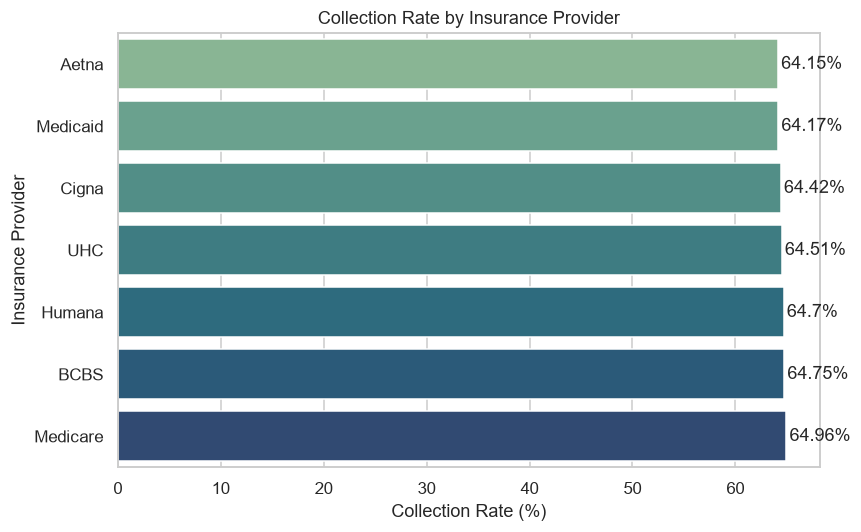

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
data_sorted = collections_by_payer.sort_values('collection_rate')
sns.barplot(x=data_sorted['collection_rate'], y=data_sorted.index, ax=ax, palette="crest")
ax.set_xlabel("Collection Rate (%)")
ax.set_ylabel("Insurance Provider")
ax.set_title("Collection Rate by Insurance Provider")
for i, v in enumerate(data_sorted['collection_rate']):
    ax.text(v + 0.3, i, f"{v}%", va='center')
plt.tight_layout()
plt.savefig(VISUALS_DIR / "collection_rate_by_payer.png")
plt.show()

**Interpretation:** Collection rates are even tighter than denial rates — every payer sits within a narrow 64.1%–65.0% band, less than 1 percentage point apart. This confirms what the denial analysis suggested: the ~35% revenue gap is a **structural, organization-wide issue**, not a problem with any single payer relationship. Interestingly, Aetna has the lowest denial rate (9.65%) but also the lowest collection rate (64.15%) — meaning even claims that get *accepted* by Aetna are being paid at a lower rate than other payers, possibly due to lower contracted reimbursement rates rather than denials. This is worth a closer look at Aetna's fee schedule specifically.

### Monthly Billed vs. Paid Trend

Tracking billed and paid amounts side by side over time shows whether the revenue gap is growing, shrinking, or holding steady.

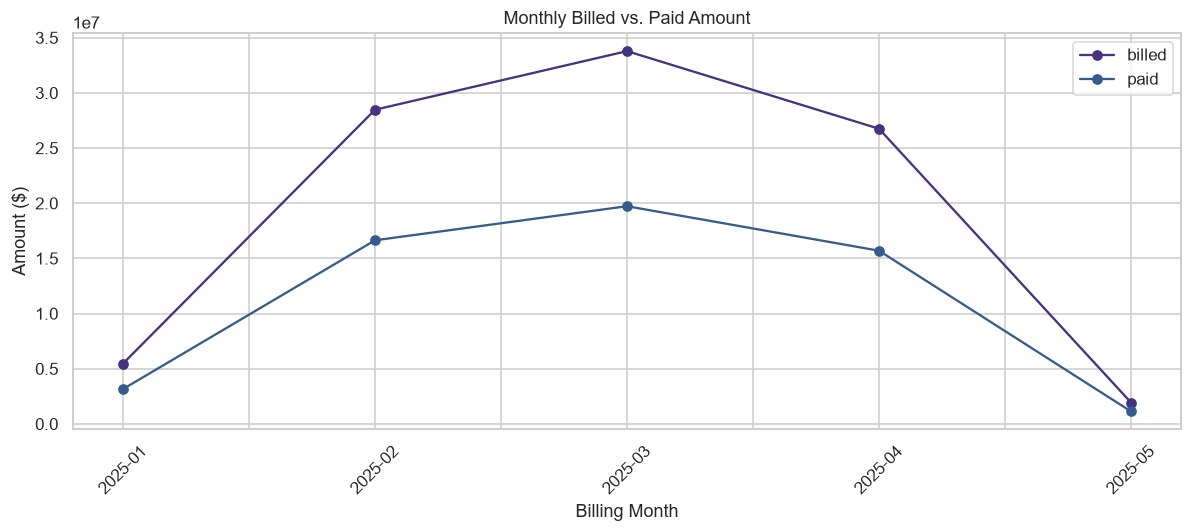

In [24]:
monthly = (
    clean.dropna(subset=['billing_month'])
    .groupby('billing_month')
    .agg(billed=('billed_amount', 'sum'), paid=('paid_amount', 'sum'))
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
monthly.plot(ax=ax, marker='o')
ax.set_ylabel("Amount ($)")
ax.set_xlabel("Billing Month")
ax.set_title("Monthly Billed vs. Paid Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "monthly_billed_vs_paid.png")
plt.show()

In [25]:
insurance['claim_billing_date'].dt.day.groupby(insurance['billing_month']).max()

billing_month
2025-01    31
2025-02    28
2025-03    31
2025-04    30
2025-05    10
Name: claim_billing_date, dtype: int32

**Interpretation:** Both billed and paid amounts rise from January through March, then decline in April, before dropping sharply in May. The May drop is **not a real decline** — `claim_billing_date` confirms May's data only extends through the 10th of the month (vs. full months for Jan–Apr), so it's an incomplete period, not a genuine collapse in billing activity. The April decline, however, is based on a complete month and may reflect a real seasonal dip worth investigating. Throughout, the proportional gap between billed and paid (the vertical distance between the two lines) stays fairly consistent — reinforcing that the ~35% collection shortfall is a stable, structural pattern rather than tied to any single month.

### Where Is Revenue Being Lost? Underpayment by Payer

Total dollar amount left uncollected (billed − paid), summed by insurance provider — this shows which payer relationships represent the biggest absolute revenue gaps, not just percentage rates.

C:\Users\USER\AppData\Local\Temp\ipykernel_3780\1209218382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=underpayment_by_payer.values, y=underpayment_by_payer.index, palette="flare", ax=ax)


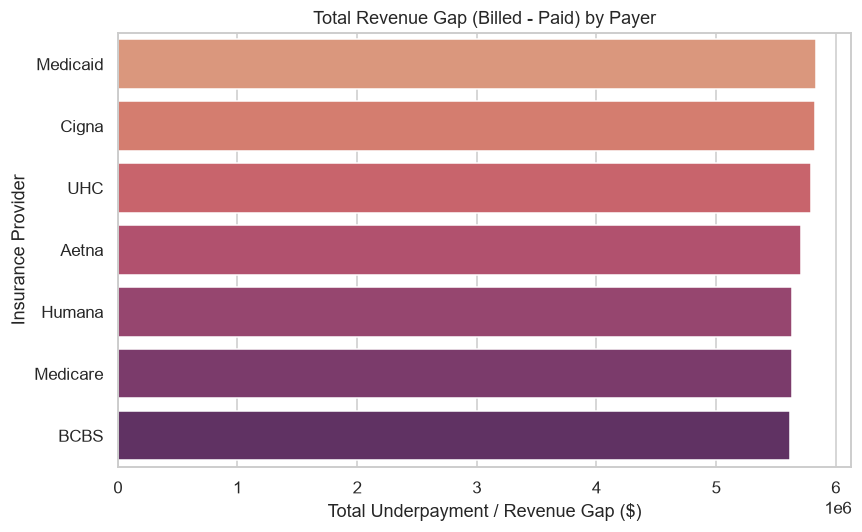

In [26]:
underpayment_by_payer = (
    clean.groupby('insurance_provider')['underpayment']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=underpayment_by_payer.values, y=underpayment_by_payer.index, palette="flare", ax=ax)
ax.set_xlabel("Total Underpayment / Revenue Gap ($)")
ax.set_ylabel("Insurance Provider")
ax.set_title("Total Revenue Gap (Billed - Paid) by Payer")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "underpayment_by_payer.png")
plt.show()

**Interpretation:** Medicaid shows the largest absolute revenue gap, followed closely by Cigna and UHC — but this ranking largely reflects **claim volume**, not payer-specific severity, since collection rates (Section 10) were nearly identical across all payers (64.1%–65.0%). In other words, Medicaid isn't losing more revenue *per claim* than other payers — it simply processes slightly more claims, so its total dollar gap is proportionally larger. This distinction matters for prioritization: fixing the *process issues* identified earlier (duplicate claims, prior authorization, timely filing) will reduce the revenue gap **across all 7 payers simultaneously**, rather than requiring payer-by-payer negotiation.

### Distribution of Billed Amounts

Understanding the shape of billed claim values — are most claims small, large, or spread evenly? This helps contextualize the dollar figures we've been working with.

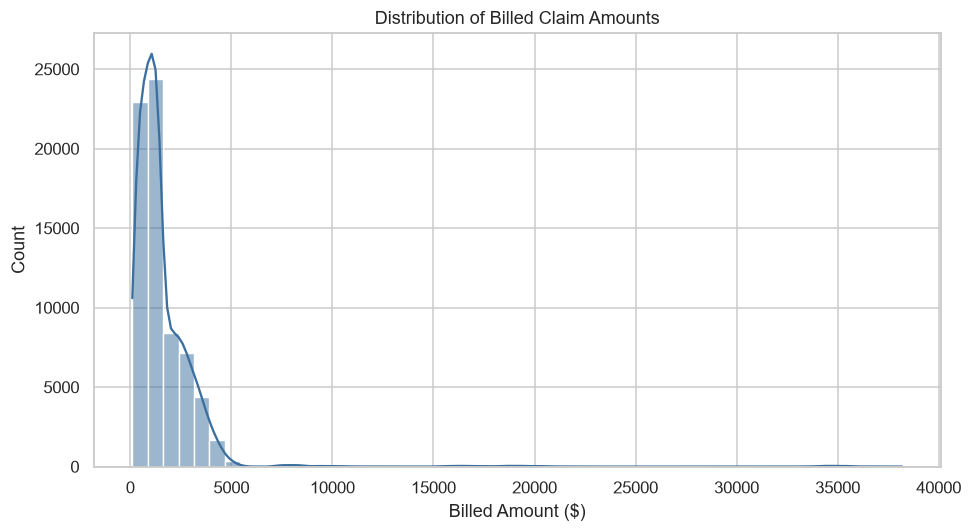

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(clean['billed_amount'], bins=50, kde=True, ax=ax, color="#3b6f9e")
ax.set_title("Distribution of Billed Claim Amounts")
ax.set_xlabel("Billed Amount ($)")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "billed_amount_distribution.png")
plt.show()

**Interpretation:** Billed amounts are heavily **right-skewed** — the vast majority of claims fall under $5,000, with a sharp peak around $1,000–$2,500, and a long thin tail stretching out to ~$38,000. This confirms what the summary statistics showed earlier (median ~$1,214 vs. mean ~$1,613 vs. max ~$38,191) — the mean is pulled upward by a small number of high-cost claims, so median is a more representative "typical claim" figure than mean. Practically, this means most of the $40M revenue gap comes from the sheer *volume* of small-to-mid-size claims being underpaid, not from a handful of catastrophic high-cost claims going unpaid.

In [28]:
pip install pyodbc sqlalchemy

Note: you may need to restart the kernel to use updated packages.


## 11. SQL Analysis (SQL Server)

Instead of an in-memory database, this analysis connects directly to a local SQL Server instance (`localhost\SQLEXPRESS`) via Windows Authentication — demonstrating a real-world workflow: Python for cleaning, SQL Server for storage and querying. The cleaned dataset will be uploaded as a table, then queried with actual T-SQL to reproduce and extend the pandas-based findings above.

In [30]:
import pyodbc
print([x for x in pyodbc.drivers() if 'SQL Server' in x])

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


### Connect to SQL Server

First establish a connection to the SQL Server instance itself (via the `master` database, SQL Server's default system database) to confirm credentials and driver setup work before creating a dedicated database.

In [33]:
import pyodbc
import sqlalchemy
from sqlalchemy import create_engine
import urllib

server = r"localhost\SQLEXPRESS"
database = "master"

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

with engine.connect() as test_conn:
    print("Connected successfully!")

Connected successfully!


### Create a Dedicated Database

Rather than storing this project's data inside `master`, create a separate database (`ClaimsBillingDB`) to keep it isolated and organized. `CREATE DATABASE` requires autocommit mode in SQL Server, since it can't run inside a multi-statement transaction.

In [36]:
autocommit_engine = engine.execution_options(isolation_level="AUTOCOMMIT")

with autocommit_engine.connect() as conn:
    conn.execute(sqlalchemy.text("CREATE DATABASE ClaimsBillingDB"))
    print("Database 'ClaimsBillingDB' created.")

Database 'ClaimsBillingDB' created.


### Reconnect to the New Database

Point the connection at `ClaimsBillingDB` instead of `master`, so all further queries and table uploads target the right place.

In [37]:
database = "ClaimsBillingDB"

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

with engine.connect() as test_conn:
    print(f"Connected to {database} successfully!")

Connected to ClaimsBillingDB successfully!


### Upload the Cleaned Data to SQL Server

Push the `clean` DataFrame (from Section 6) into SQL Server as a table called `claims`, so we can query it with real T-SQL.

In [38]:
clean.to_sql("claims", engine, if_exists="replace", index=False)
print("Data uploaded to SQL Server table 'claims'.")

Data uploaded to SQL Server table 'claims'.


### Query 1 — Denial Rate by Payer (SQL Server)

Reproduce the denial-rate-by-payer analysis from Section 9, but written as a T-SQL query instead of pandas.

In [39]:
query_1 = """
SELECT insurance_provider,
       COUNT(*) AS total_claims,
       SUM(CASE WHEN claim_status = 'Denied' THEN 1 ELSE 0 END) AS denied_claims,
       ROUND(100.0 * SUM(CASE WHEN claim_status = 'Denied' THEN 1 ELSE 0 END) / COUNT(*), 2) AS denial_rate_pct
FROM claims
WHERE payment_method = 'Insurance'
GROUP BY insurance_provider
ORDER BY denial_rate_pct DESC;
"""
pd.read_sql(query_1, engine)

,insurance_provider,total_claims,denied_claims,denial_rate_pct
0,Medicaid,8572,934,10.90
1,Cigna,8481,871,10.27
2,Humana,8450,844,9.99
3,UHC,8592,855,9.95
4,Medicare,8460,833,9.85
5,BCBS,8516,834,9.79
6,Aetna,8567,827,9.65


### Query 2 — Collection Rate by Payer (SQL Server)

Reproduce the collection-rate-by-payer analysis from Section 10.

In [40]:
query_2 = """
SELECT insurance_provider,
       ROUND(SUM(billed_amount), 2) AS total_billed,
       ROUND(SUM(paid_amount), 2) AS total_paid,
       ROUND(100.0 * SUM(paid_amount) / SUM(billed_amount), 2) AS collection_rate_pct
FROM claims
GROUP BY insurance_provider
ORDER BY collection_rate_pct ASC;
"""
pd.read_sql(query_2, engine)

,insurance_provider,total_billed,total_paid,collection_rate_pct
0,Aetna,15931881.91,10220394.03,64.15
1,Medicaid,16297387.90,10458464.11,64.17
2,Cigna,16379391.57,10552126.52,64.42
3,UHC,16328640.75,10533344.33,64.51
4,Humana,15957291.04,10324831.81,64.70
5,BCBS,15937527.71,10319121.06,64.75
6,Medicare,16068518.96,10437368.68,64.96


### Query 3 — Top 5 Denial Reasons (SQL Server)

Reproduce the top-denial-reasons analysis from Section 9.

In [41]:
query_3 = """
SELECT TOP 5 denial_reason, COUNT(*) AS occurrences
FROM claims
WHERE claim_status = 'Denied'
GROUP BY denial_reason
ORDER BY occurrences DESC;
"""
pd.read_sql(query_3, engine)

,denial_reason,occurrences
0,Duplicate Claim,472
1,Prior Authorization Required,457
2,Timely Filing Limit Exceeded,437
3,Service Not Covered,437
4,Coordination of Benefits Issue,436


## 12. Key Findings & Recommendations



In [42]:
print("=== SUMMARY OF KEY FINDINGS ===\n")
print(f"1. Overall collection rate: {overall_collection_rate:.1%} of billed revenue is collected.")
print(f"   -> Total revenue gap: ${total_underpayment:,.0f} across {len(clean):,} claims.\n")

worst_payer = denial_by_payer['denial_rate'].idxmax()
worst_rate = denial_by_payer['denial_rate'].max()
print(f"2. Highest denial rate payer: {worst_payer} at {worst_rate}% — "
      f"a priority target for the billing team.\n")

top_reason = top_reasons.index[0]
print(f"3. Leading denial cause: '{top_reason}' ({top_reasons.iloc[0]} claims).\n")

best_collector = collections_by_payer['collection_rate'].idxmax()
worst_collector = collections_by_payer['collection_rate'].idxmin()
print(f"4. Best-collecting payer: {best_collector} "
      f"({collections_by_payer.loc[best_collector, 'collection_rate']}%). "
      f"Weakest: {worst_collector} "
      f"({collections_by_payer.loc[worst_collector, 'collection_rate']}%).")

=== SUMMARY OF KEY FINDINGS ===

1. Overall collection rate: 64.5% of billed revenue is collected.
   -> Total revenue gap: $40,054,989 across 70,000 claims.

2. Highest denial rate payer: Medicaid at 10.9% — a priority target for the billing team.

3. Leading denial cause: 'Duplicate Claim' (472 claims).

4. Best-collecting payer: Medicare (64.96%). Weakest: Aetna (64.15%).


### Recommendations
1. **Target Medicaid and Cigna first** for a root-cause review of claim submission — they have the highest denial rates, though the gap across all payers is narrow (9.65%–10.9%), suggesting internal process issues rather than payer-specific ones.
2. **Fix the top denial reasons** — Duplicate Claim, Prior Authorization Required, and Timely Filing Limit Exceeded are all preventable through better front-desk workflows and pre-submission checklists, not payer negotiation.
3. **Track denial rate and collection rate monthly** as standing KPIs (via the Power BI dashboard) so process fixes can be measured against a real trend, not a single snapshot.
4. **Investigate Aetna's lower collection rate** (64.15%, despite having the *lowest* denial rate) — this points to a fee-schedule or reimbursement-rate issue rather than a denial issue, and needs a different fix.
5. **Feed `data/clean/claims_and_billing_clean.csv` into Power BI** for a live, filterable dashboard the revenue cycle team can monitor ongoing.

---
*Data note: this dataset covers January–May 2025, with May only partially represented (through the 10th). Trend conclusions should be treated as preliminary until a full month of May data is available.*
"""